## KNN Model Training

### Normalize features


In [11]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('data/tracks.csv')  
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (114000, 20)


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## Exploratory Data Analysis

In [12]:
# Check basic info
print("Dataset Info:")
print(df.info())
print(f"\nMissing values:\n{df.isnull().sum()}")

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  str    
 1   artists           113999 non-null  str    
 2   album_name        113999 non-null  str    
 3   track_name        113999 non-null  str    
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence          

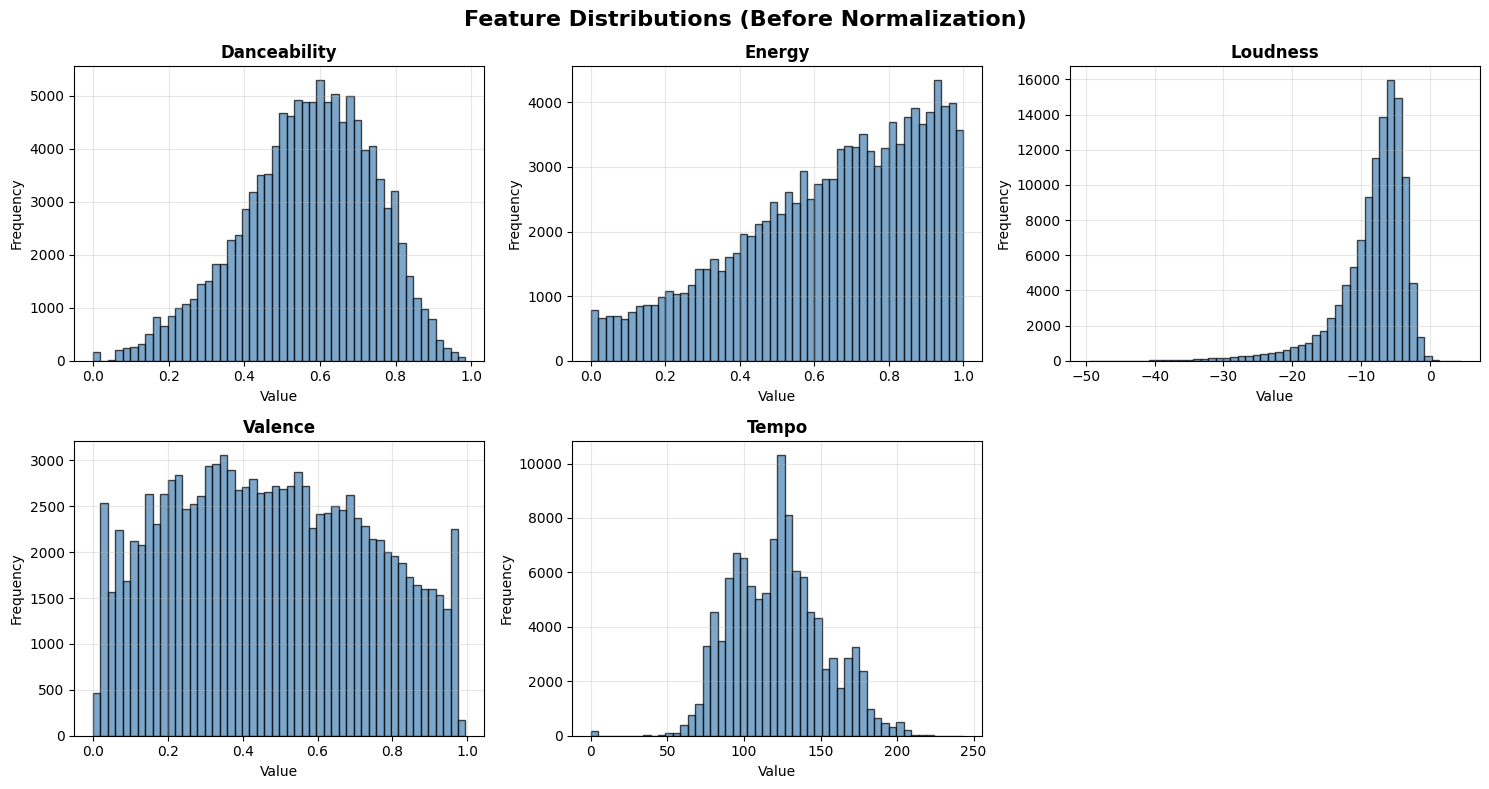

In [13]:
# Feature distributions for our 5 selected features
features_to_viz = ['danceability', 'energy', 'loudness', 'valence', 'tempo']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Feature Distributions (Before Normalization)', fontsize=16, fontweight='bold')

for idx, feature in enumerate(features_to_viz):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    ax.hist(df[feature].dropna(), bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    ax.set_title(f'{feature.capitalize()}', fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.grid(alpha=0.3)

# Remove the empty subplot
axes[1, 2].remove()

plt.tight_layout()
plt.show()

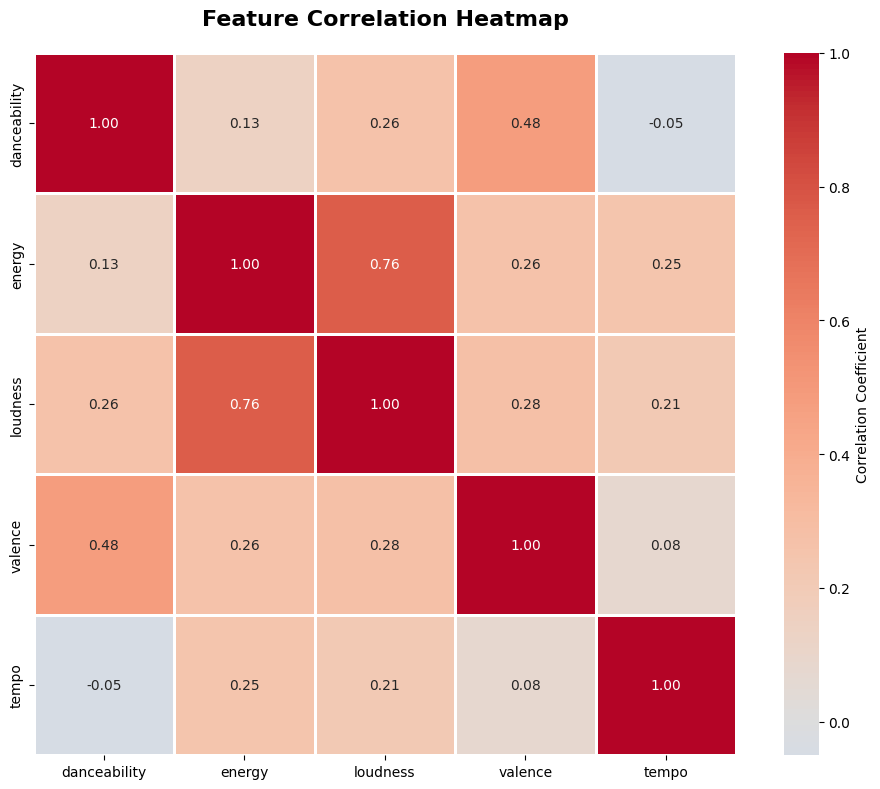


Key correlations:
energy        loudness        0.761690
loudness      energy          0.761690
danceability  valence         0.477341
valence       danceability    0.477341
loudness      valence         0.279848
dtype: float64


In [14]:
# Correlation heatmap for the 5 features
plt.figure(figsize=(10, 8))
correlation_matrix = df[features_to_viz].corr()

sns.heatmap(correlation_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm', 
            center=0,
            square=True,
            linewidths=1,
            cbar_kws={'label': 'Correlation Coefficient'})

plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\nKey correlations:")
# Get the top correlations (excluding diagonal)
corr_pairs = correlation_matrix.unstack()
corr_pairs = corr_pairs[corr_pairs < 1.0].sort_values(ascending=False)
print(corr_pairs.head(5))

## Data Processing & Export

In [15]:

features = ['danceability', 'energy', 'loudness', 'valence', 'tempo']
metadata = ['track_id', 'track_name', 'artists', 'album_name', 'track_genre']

df_clean = df[metadata + features].dropna()

print(f"Original dataset: {len(df)} tracks")
print(f"After removing missing values: {len(df_clean)} tracks")
print(f"\nFeatures to normalize: {features}")

Original dataset: 114000 tracks
After removing missing values: 113999 tracks

Features to normalize: ['danceability', 'energy', 'loudness', 'valence', 'tempo']


In [16]:

print("Feature ranges BEFORE normalization:")
for feat in features:
    print(f"{feat:20s}: [{df_clean[feat].min():.2f}, {df_clean[feat].max():.2f}]")

Feature ranges BEFORE normalization:
danceability        : [0.00, 0.98]
energy              : [0.00, 1.00]
loudness            : [-49.53, 4.53]
valence             : [0.00, 0.99]
tempo               : [0.00, 243.37]


In [17]:

scaler = MinMaxScaler()
df_clean[features] = scaler.fit_transform(df_clean[features])

print("Features normalized!")
print(f"\nSample of normalized data:")
df_clean.head()

Features normalized!

Sample of normalized data:


,track_id,track_name,artists,album_name,track_genre,danceability,energy,loudness,valence,tempo
0,5SuOikwiRyPMVoIQDJUgSV,Comedy,Gen Hoshino,Comedy,acoustic,0.686294,0.4610,0.791392,0.718593,0.361245
1,4qPNDBW1i3p13qLCt0Ki3A,Ghost - Acoustic,Ben Woodward,Ghost (Acoustic),acoustic,0.426396,0.1660,0.597377,0.268342,0.318397
2,1iJBSr7s7jYXzM8EGcbK5b,To Begin Again,Ingrid Michaelson;ZAYN,To Begin Again,acoustic,0.444670,0.3590,0.736123,0.120603,0.313643
3,6lfxq3CG4xtTiEg7opyCyx,Can't Help Falling In Love,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,acoustic,0.270051,0.0596,0.573701,0.143719,0.746758
4,5vjLSffimiIP26QG5WcN2K,Hold On,Chord Overstreet,Hold On,acoustic,0.627411,0.4430,0.737103,0.167839,0.492863


In [18]:
print("Feature ranges AFTER normalization:")
for feat in features:
    print(f"{feat:20s}: [{df_clean[feat].min():.2f}, {df_clean[feat].max():.2f}]")

Feature ranges AFTER normalization:
danceability        : [0.00, 1.00]
energy              : [0.00, 1.00]
loudness            : [0.00, 1.00]
valence             : [0.00, 1.00]
tempo               : [0.00, 1.00]


In [19]:
# Save processed data to CSV
output_path = 'data/tracks_processed.csv'
df_clean.to_csv(output_path, index=False)

print(f"✓ Processed data saved to {output_path}")
print(f"✓ Shape: {df_clean.shape}")
print(f"✓ Columns: {list(df_clean.columns)}")

✓ Processed data saved to data/tracks_processed.csv
✓ Shape: (113999, 10)
✓ Columns: ['track_id', 'track_name', 'artists', 'album_name', 'track_genre', 'danceability', 'energy', 'loudness', 'valence', 'tempo']
